In [16]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [2]:
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


EXPLORATORY DATA ANALYSIS

In [6]:
Class_churn=df["Churn"].value_counts()

In [7]:
Class_churn

Churn
No     5174
Yes    1869
Name: count, dtype: int64

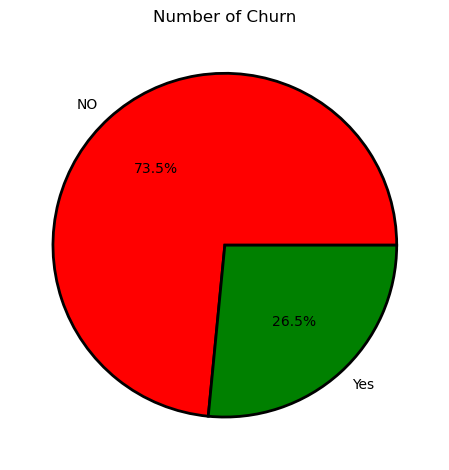

In [8]:
plt.pie(
    Class_churn,
    labels=["NO","Yes"],
    autopct="%1.1f%%",
    colors=['r','g'],
    wedgeprops={
        'linewidth': 2,
        'edgecolor': "black"
    }
)
plt.title("Number of Churn")
plt.tight_layout()


In [9]:
class_phone_service=df["PhoneService"].value_counts()

In [10]:
class_phone_service

PhoneService
Yes    6361
No      682
Name: count, dtype: int64

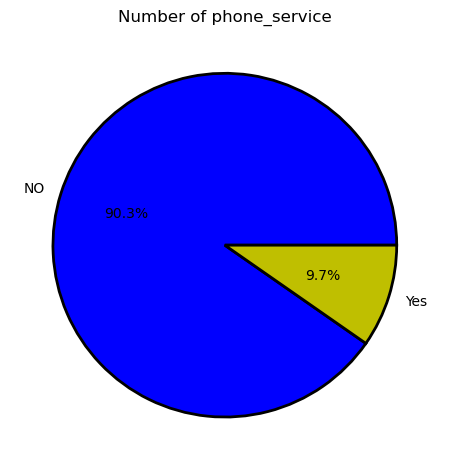

In [11]:
plt.pie(
    class_phone_service,
    labels=["NO","Yes"],
    autopct="%1.1f%%",
    colors=['b','y'],
    wedgeprops={
        'linewidth': 2,
        'edgecolor': "black"
    }
)
plt.title("Number of phone_service")
plt.tight_layout()


In [12]:
class_Contract=df["Contract"].value_counts()

In [13]:
class_Contract

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

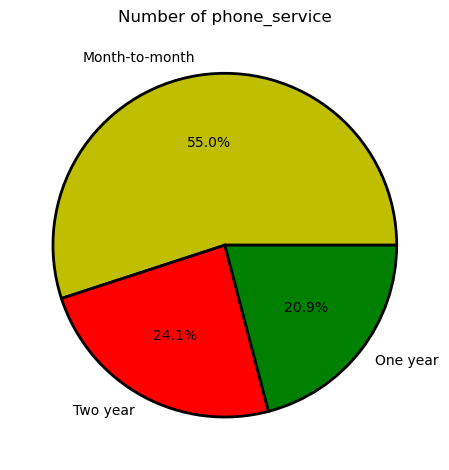

In [14]:
plt.pie(
    class_Contract,
    labels=["Month-to-month","Two year","One year"],
    autopct="%1.1f%%",
    colors=['y','r','g'],
    wedgeprops={
        'linewidth': 2,
        'edgecolor': "black"
    }
)
plt.title("Number of phone_service")
plt.tight_layout()


In [21]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

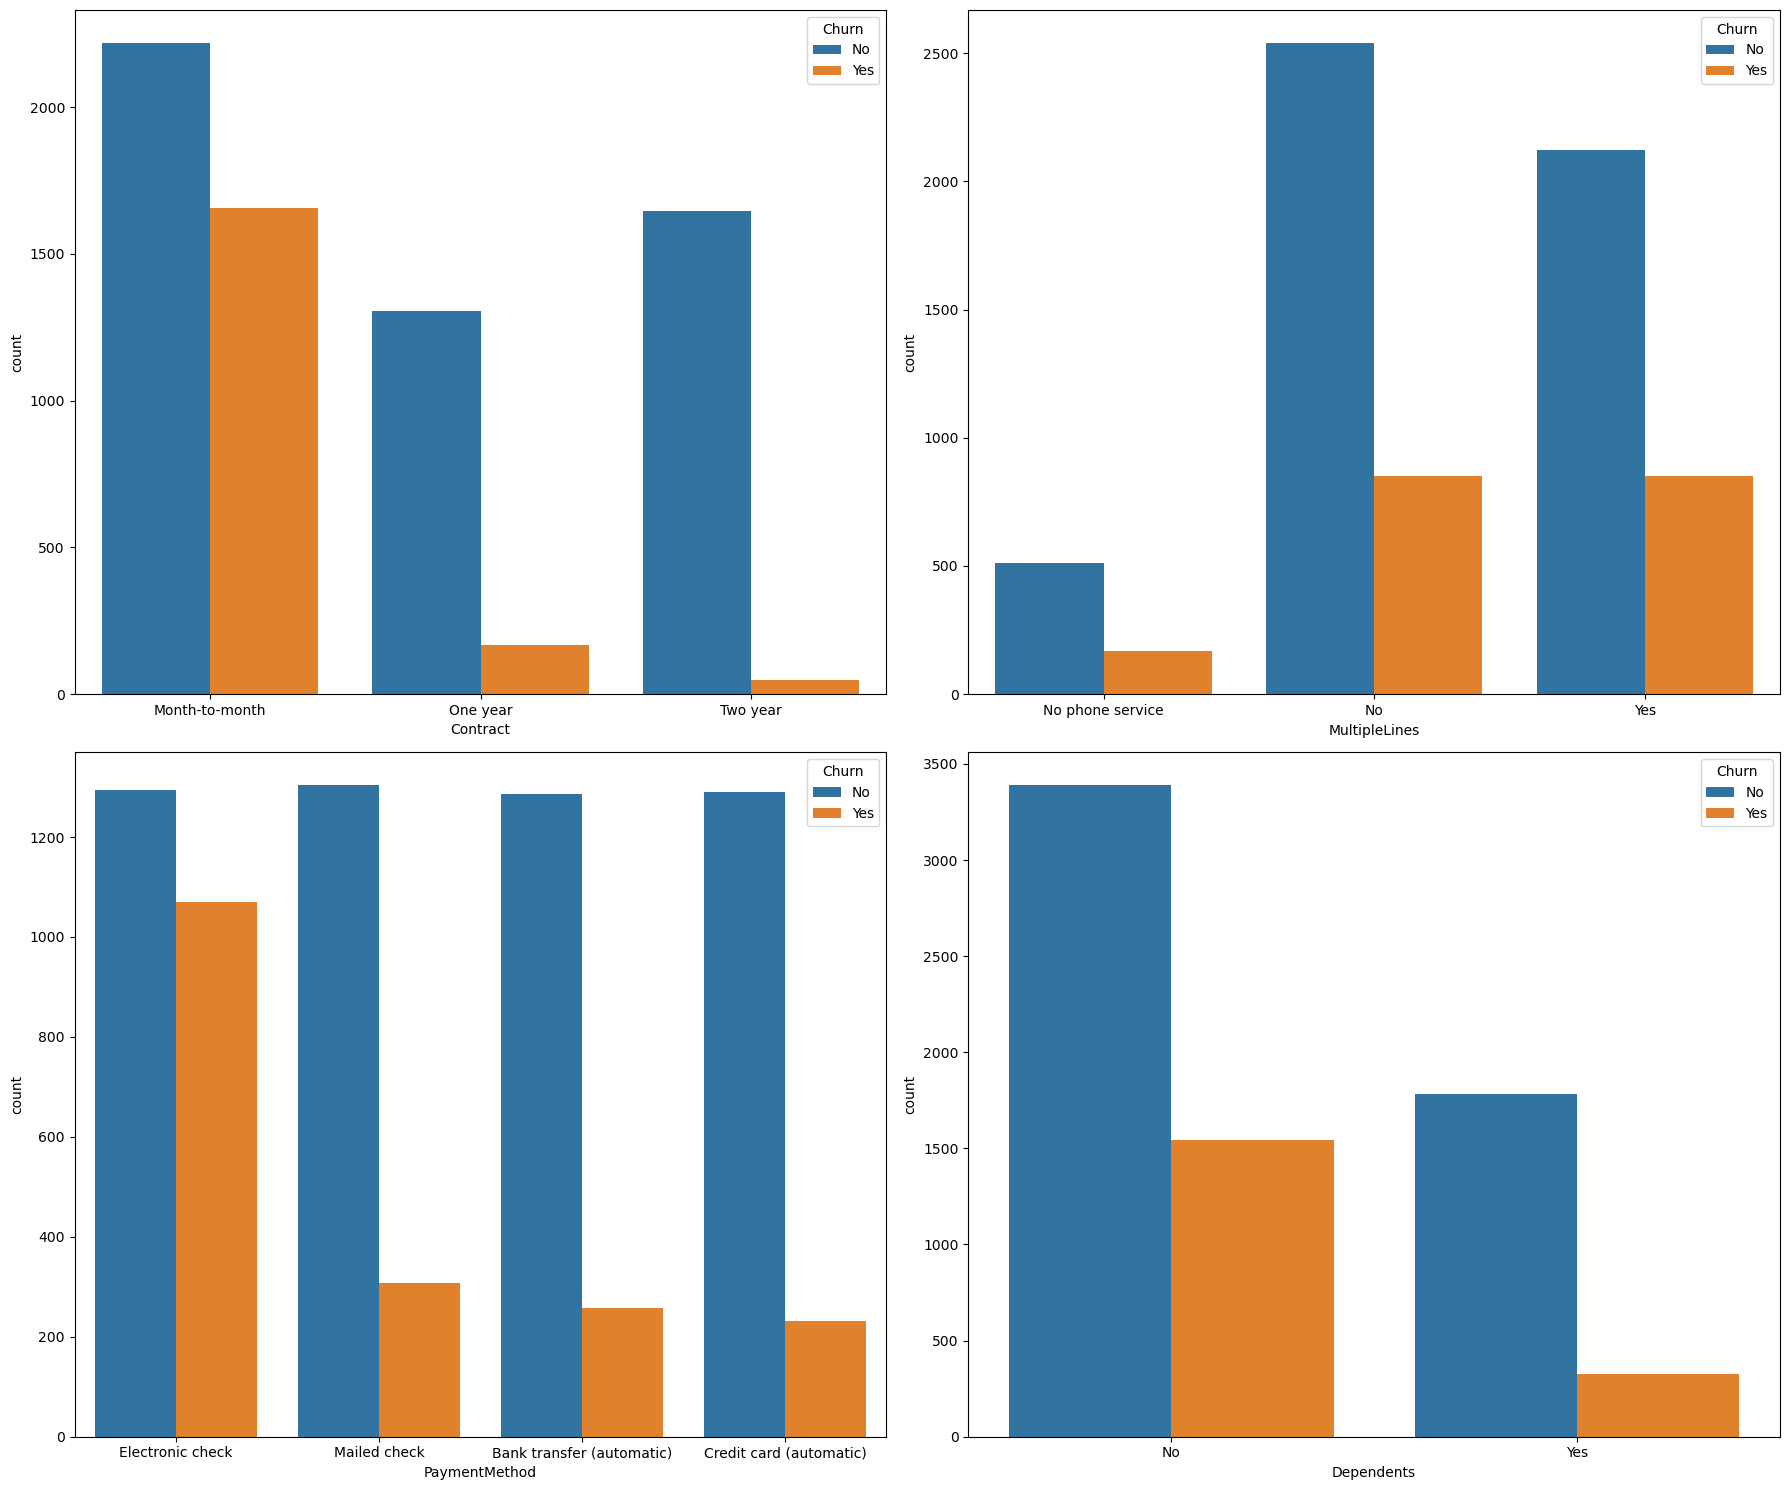

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(18, 15))
sns.countplot(ax=axes[0,0], data=df, x='Contract', hue="Churn")
sns.countplot(ax=axes[0,1], data=df, x='MultipleLines', hue="Churn")
sns.countplot(ax=axes[1,0], data=df, x='PaymentMethod', hue="Churn")
sns.countplot(ax=axes[1,1], data=df, x='Dependents', hue="Churn")
plt.tight_layout()